# 02c — Mid-level PLS + QDA fusion classifier

**CAC2026 Data Challenge — olive oil musty-defect detection (scored by F1).**

Same mid-level data-fusion pipeline as `02a`, but the final classifier on the
fused scores is **QDA (Quadratic Discriminant Analysis)** instead of PLS-DA:

```
X_hsms ──PLS-DA(LV)──► T_hsms ┐
X_mir  ──PLS-DA(LV)──► T_mir  ├─ hstack ─► [scale] ─► QDA ─► musty / not-musty
X_uvvis──PLS-DA(LV)──► T_uvvis┘
```

Everything heavy lives in the `olive_oil` package; this notebook only **configures
and runs** it. You set, per block:

1. the **spectral window** (`region`),
2. the **preprocessing recipe** (`steps`), and
3. an optional list of **outlier sample IDs** to discard (default: none).

QDA has **no hyperparameters to tune** here (default, no regularisation), so
the coarse-to-fine grid search spans only the **block PLS latent variables** and
**fused-score scaling**, under nested cross-validation for an honest F1 estimate.

> Block configuration and preprocessing are kept identical to `02a`'s best run so
> the only thing that changes is the final classifier — making the F1 directly
> comparable (02a PLS-DA reference: **0.765 ± 0.052**).

In [1]:
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)

# Quiet sklearn's convergence / undefined-metric chatter during the CV sweeps.
warnings.filterwarnings("ignore")

from olive_oil import (
    load_dataset,
    BlockConfig,
    prepare_blocks,
    MidLevelFusionClassifier,
    nested_cv,
    tune_final_model,
    predict_test,
    make_cv,
)
from olive_oil.visualization import plot_spectra

# Resolve the project root whether the notebook runs from Notebooks/ or the root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "CAC2026_Data_challenge.xlsx"
DATA_PATH

WindowsPath('C:/Users/SamdGuizani/OneDrive/Documents/Data Science & Coding/2026-Olive Oil Classification (CAC 2026)/CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics/Data/CAC2026_Data_challenge.xlsx')

## 1. Load the data

`load_dataset` reads all eight sheets. Spectral sheets keep their replicates;
`prepare_blocks` (below) averages them per sample.

In [2]:
raw = load_dataset(DATA_PATH)
labels = raw["labels"]
print("Calibration samples:", labels.shape[0])
print("Class balance (0 = not musty, 1 = musty):",
      labels["label"].value_counts().sort_index().to_dict())
print("Musty prevalence:", round(labels["label"].mean(), 3))

Calibration samples: 220
Class balance (0 = not musty, 1 = musty): {0: 144, 1: 76}
Musty prevalence: 0.345


## 2. Configure the blocks

Identical to `02a`'s best configuration (so the QDA-vs-PLS-DA comparison is clean).
Each block gets a **spectral window** and a **preprocessing recipe** — change the
`region` bounds and `steps` freely to explore.

**Steps** are applied in order, after region selection. Available steps:
`row_profile`, `log`, `snv`, `savgol_derivative`, `mean_center`.

> **Leakage note:** the per-sample steps (`row_profile`, `log`, `snv`,
> `savgol_derivative`) are computed independently per spectrum. `mean_center` is
> fit on the calibration set and the same column means are reused on the test set.

In [3]:
# Per-block spectral window + preprocessing recipe (same as 02a best run).
configs = {
    "hsms": BlockConfig(
        region=(100, 125),
        steps=["row_profile", "log", "mean_center"],
    ),
    "mir": BlockConfig(
        region=(1500, 700),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
    "uvvis": BlockConfig(
        region=(300, 1000),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
}

# Calibration sample IDs to discard as outliers (default: none).
outliers = []

data = prepare_blocks(raw, configs, outliers=outliers)
print("Discarded outliers:", data.discarded_ids or "none")
print("Block order:", data.block_names)
data.summary()

Discarded outliers: none
Block order: ['hsms', 'mir', 'uvvis']


,n_variables,axis_min,axis_max,n_train,n_test
block,,,,,
hsms,26,100.00000,125.000000,220,24
mir,208,700.04498,1498.443334,220,24
uvvis,701,300.00000,1000.000000,220,24


### Sanity-check the preprocessed spectra (optional)

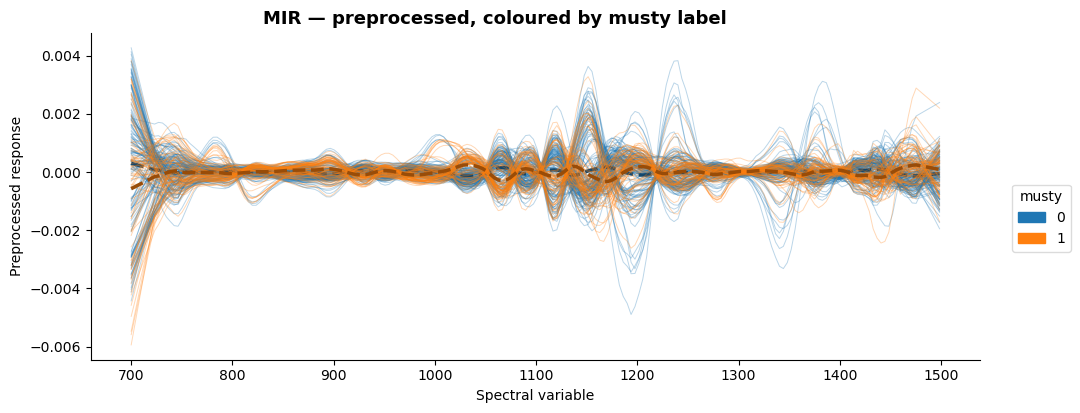

In [4]:
block = "mir"  # try "hsms" / "uvvis" too
i = data.block_names.index(block)
spectra = (data.X_train[i], data.axes[block], data.train_ids)
label_meta = raw["labels"].rename(columns={"label": "musty"})

g = plot_spectra(
    spectra, metadata=label_meta, color_by="musty",
    xlabel="Spectral variable", ylabel="Preprocessed response",
    title=f"{block.upper()} — preprocessed, coloured by musty label",
)

## 3. Build the coarse hyperparameter grid

QDA is **parameter-free** here, so the only hyperparameters left are the per-block
PLS latent variables and the fused-score scaling:

| Hyperparameter | Meaning | Coarse range |
|---|---|---|
| `n_components_list[0]` (hsms) | block PLS-DA latent variables | `4, 6, 8, 10, 12` |
| `n_components_list[1]` (mir)  | block PLS-DA latent variables | `9, 12, 15, 18, 21, 24` |
| `n_components_list[2]` (uvvis)| block PLS-DA latent variables | `3, 6, 9, 12` |
| `scale_fused`                 | StandardScale fused scores | `True, False` |

`n_components_list` is one tuple parameter, so the search uses the **Cartesian
product** of the per-block ranges. Dropping the final-LV dimension makes this grid
much smaller than 02a's (no `classifier__n_components` to sweep).

In [5]:
# Per-block latent-variable ranges (coarse) — same as 02a for comparability.
LV_HSMS  = (4, 6, 8, 10, 12)
LV_MIR   = (9, 12, 15, 18, 21, 24)
LV_UVVIS = (3, 6, 9, 12)

# Cartesian product -> list of (hsms, mir, uvvis) tuples (tuples, for GridSearchCV).
component_grid = [tuple(t) for t in product(LV_HSMS, LV_MIR, LV_UVVIS)]

param_grid = {
    "n_components_list": component_grid,
    "scale_fused": [True, False],
}

n_configs = len(component_grid) * 2
print(f"Component tuples : {len(component_grid)}")
print(f"Total configs    : {n_configs}")
print(f"Inner fits/outer : {n_configs} x 3 folds = {n_configs*3}")
print(f"Nested fits total: ~{n_configs*3*5} (5 outer folds)  -> fast with n_jobs=-1")

Component tuples : 120
Total configs    : 240
Inner fits/outer : 240 x 3 folds = 720
Nested fits total: ~3600 (5 outer folds)  -> fast with n_jobs=-1


## 4. Define the model

QDA as the final classifier on the fused scores (curved boundary). It exposes no hyperparameters we
tune here; `scale_fused` is searched, so its value below is just a placeholder the
grid overrides.

In [6]:
model = MidLevelFusionClassifier(
    classifier=QuadraticDiscriminantAnalysis(),   # parameter-free; swap for SVC in 02d+
    scale_fused=True,
)

## 5. Nested cross-validation — the honest F1 estimate

Inner `GridSearchCV` (3-fold) tunes the grid on each outer training split; outer
`cross_validate` (5-fold) scores F1/precision/recall on the held-out outer fold.
The **outer test mean ± std** is the unbiased estimate to report.

In [7]:
nested = nested_cv(
    model, param_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)

print("Outer-fold performance (mean ± std):")
display(nested["summary"].round(3))

f1 = nested["raw"]["test_f1"]
coarse_nested_f1 = f1.mean()
print("Per-fold F1:", np.round(f1, 3))
print(f"Nested-CV F1 (coarse grid): {f1.mean():.3f} +/- {f1.std():.3f}")
print("\nWinning hyperparameters per outer fold:")
for k, p in enumerate(nested["best_params"]):
    print(f"  fold {k}: {p}")

Outer-fold performance (mean ± std):


,test_mean,test_std,train_mean,train_std
metric,,,,
f1,0.688,0.066,0.915,0.027
precision,0.696,0.065,0.926,0.027
recall,0.686,0.090,0.905,0.032


Per-fold F1: [0.621 0.774 0.759 0.667 0.621]
Nested-CV F1 (coarse grid): 0.688 +/- 0.066

Winning hyperparameters per outer fold:
  fold 0: {'n_components_list': (4, 9, 6), 'scale_fused': True}
  fold 1: {'n_components_list': (4, 9, 3), 'scale_fused': True}
  fold 2: {'n_components_list': (4, 9, 9), 'scale_fused': True}
  fold 3: {'n_components_list': (4, 12, 6), 'scale_fused': True}
  fold 4: {'n_components_list': (10, 9, 3), 'scale_fused': True}


## 6. Refit on all calibration data (coarse grid)

A single `GridSearchCV` over the full calibration set selects the latent-variable
counts and refits the model. Its `best_score_` is the inner-CV F1 of the winner —
optimistic versus the nested estimate above, which stays the number to report.

In [8]:
search = tune_final_model(
    model, param_grid,
    data.train_blocks(), data.y,
    cv=make_cv(5, random_state=0),
)
print("Best hyperparameters:", search.best_params_)
print("Best inner-CV F1     :", round(search.best_score_, 3))

Best hyperparameters: {'n_components_list': (4, 9, 3), 'scale_fused': True}
Best inner-CV F1     : 0.74


## 7. Explore the search landscape

In [9]:
res = pd.DataFrame(search.cv_results_)
lv = pd.DataFrame(res["param_n_components_list"].tolist(),
                  index=res.index, columns=["lv_hsms", "lv_mir", "lv_uvvis"])
res = pd.concat([res, lv], axis=1)
res["scale_fused"] = res["param_scale_fused"]

show_cols = ["lv_hsms", "lv_mir", "lv_uvvis", "scale_fused",
             "mean_test_score", "std_test_score", "rank_test_score"]
print("Top 15 configurations by mean CV F1:")
display(res.sort_values("rank_test_score")[show_cols].head(15).round(3).reset_index(drop=True))

Top 15 configurations by mean CV F1:


,lv_hsms,lv_mir,lv_uvvis,scale_fused,mean_test_score,std_test_score,rank_test_score
0,4,9,3,True,0.740,0.058,1
1,4,9,3,False,0.740,0.058,1
2,4,12,12,False,0.730,0.057,3
3,4,12,12,True,0.730,0.057,3
4,4,9,6,True,0.721,0.072,5
5,4,9,6,False,0.721,0.072,5
6,4,9,9,True,0.721,0.064,7
7,4,9,9,False,0.721,0.064,7
8,8,9,3,True,0.719,0.062,9
9,8,9,3,False,0.719,0.062,9


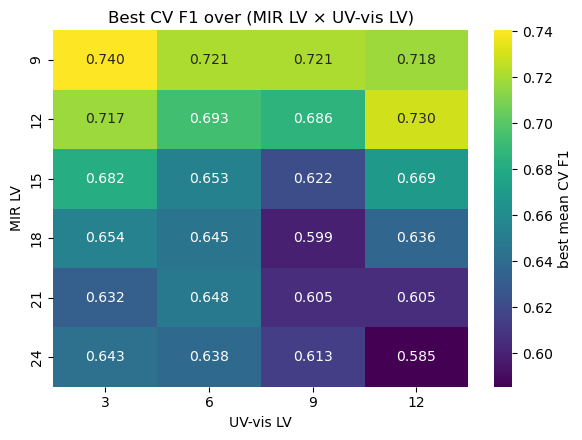

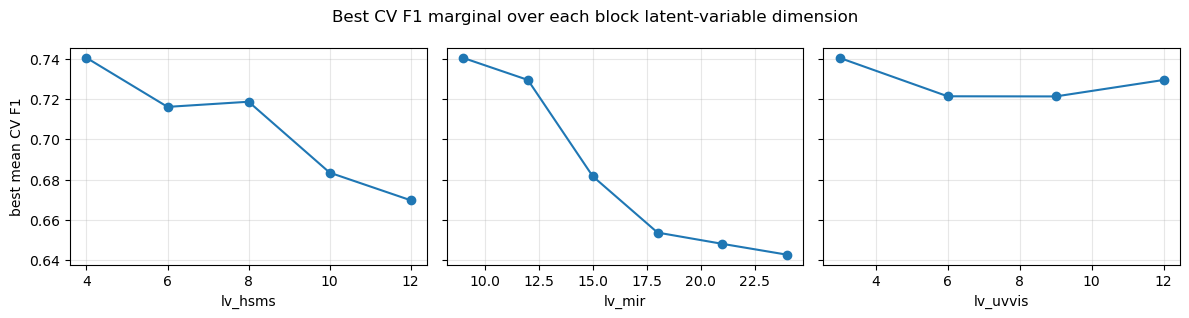

In [10]:
# (a) Heatmap: best CV F1 for each (mir, uvvis) LV pair (max over the other params).
piv = res.pivot_table(index="lv_mir", columns="lv_uvvis",
                      values="mean_test_score", aggfunc="max")
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={"label": "best mean CV F1"})
ax.set_title("Best CV F1 over (MIR LV × UV-vis LV)")
ax.set_xlabel("UV-vis LV"); ax.set_ylabel("MIR LV")
plt.tight_layout(); plt.show()

# (b) Marginal: best CV F1 against each block LV dimension (max over the others).
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, col in zip(axes, ["lv_hsms", "lv_mir", "lv_uvvis"]):
    gmax = res.groupby(col)["mean_test_score"].max()
    ax.plot(gmax.index, gmax.values, "o-")
    ax.set_xlabel(col); ax.grid(alpha=0.3)
axes[0].set_ylabel("best mean CV F1")
fig.suptitle("Best CV F1 marginal over each block latent-variable dimension")
plt.tight_layout(); plt.show()

## 8. Fine grid around the coarse winner (optional refinement)

Zoom into a ±2-LV neighbourhood of the coarse winner (the coarse grid steps by 3,
so ±2 fills the gaps). To keep the reported F1 **honest**, we re-run nested CV on
the fine grid too and compare it against the coarse estimate before deploying.

In [11]:
def neighbours(value, lo, hi, span=2):
    return sorted({max(lo, min(hi, value + d)) for d in range(-span, span + 1)})

best = search.best_params_
b_hsms, b_mir, b_uvvis = best["n_components_list"]

fine_components = [
    tuple(t) for t in product(
        neighbours(b_hsms, 1, 14),
        neighbours(b_mir, 1, 28),
        neighbours(b_uvvis, 1, 18),
    )
]

fine_grid = {
    "n_components_list": fine_components,
    "scale_fused": [best["scale_fused"]],   # lock to the coarse-chosen value
}
print("Fine component tuples:", fine_components)
print("Fine configs         :", len(fine_components))

Fine component tuples: [(2, 7, 1), (2, 7, 2), (2, 7, 3), (2, 7, 4), (2, 7, 5), (2, 8, 1), (2, 8, 2), (2, 8, 3), (2, 8, 4), (2, 8, 5), (2, 9, 1), (2, 9, 2), (2, 9, 3), (2, 9, 4), (2, 9, 5), (2, 10, 1), (2, 10, 2), (2, 10, 3), (2, 10, 4), (2, 10, 5), (2, 11, 1), (2, 11, 2), (2, 11, 3), (2, 11, 4), (2, 11, 5), (3, 7, 1), (3, 7, 2), (3, 7, 3), (3, 7, 4), (3, 7, 5), (3, 8, 1), (3, 8, 2), (3, 8, 3), (3, 8, 4), (3, 8, 5), (3, 9, 1), (3, 9, 2), (3, 9, 3), (3, 9, 4), (3, 9, 5), (3, 10, 1), (3, 10, 2), (3, 10, 3), (3, 10, 4), (3, 10, 5), (3, 11, 1), (3, 11, 2), (3, 11, 3), (3, 11, 4), (3, 11, 5), (4, 7, 1), (4, 7, 2), (4, 7, 3), (4, 7, 4), (4, 7, 5), (4, 8, 1), (4, 8, 2), (4, 8, 3), (4, 8, 4), (4, 8, 5), (4, 9, 1), (4, 9, 2), (4, 9, 3), (4, 9, 4), (4, 9, 5), (4, 10, 1), (4, 10, 2), (4, 10, 3), (4, 10, 4), (4, 10, 5), (4, 11, 1), (4, 11, 2), (4, 11, 3), (4, 11, 4), (4, 11, 5), (5, 7, 1), (5, 7, 2), (5, 7, 3), (5, 7, 4), (5, 7, 5), (5, 8, 1), (5, 8, 2), (5, 8, 3), (5, 8, 4), (5, 8, 5), (5, 9, 1), 

In [12]:
nested_fine = nested_cv(
    model, fine_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)
fine_nested_f1 = nested_fine["raw"]["test_f1"].mean()

fine_search = tune_final_model(
    model, fine_grid, data.train_blocks(), data.y, cv=make_cv(5, random_state=0),
)

print(f"Coarse nested-CV F1: {coarse_nested_f1:.3f}")
print(f"Fine   nested-CV F1: {fine_nested_f1:.3f}")
print("Fine best params   :", fine_search.best_params_)

Coarse nested-CV F1: 0.688
Fine   nested-CV F1: 0.684
Fine best params   : {'n_components_list': (2, 7, 5), 'scale_fused': True}


## 9. Deploy the best model

Pick whichever grid gave the better **honest (nested)** F1; its `tune_final_model`
search is already refit on all calibration data.

In [13]:
if fine_nested_f1 >= coarse_nested_f1:
    final_search, tag, headline_f1 = fine_search, "fine", fine_nested_f1
else:
    final_search, tag, headline_f1 = search, "coarse", coarse_nested_f1

print(f"Deploying the {tag}-grid model "
      f"(nested-CV F1 = {headline_f1:.3f}; params = {final_search.best_params_})")

Deploying the coarse-grid model (nested-CV F1 = 0.688; params = {'n_components_list': (4, 9, 3), 'scale_fused': True})


## 10. Training-set fit of the deployed model

Scores of the deployed model on the **calibration set it was fitted on**
(resubstitution): F1, Precision, Recall and Inaccuracy (% misclassified).

> These are **optimistic** — the model has seen these samples. The honest
> generalization estimate stays the nested-CV F1 (§5). The gap between the two is
> a useful overfitting diagnostic.

In [14]:
y_train_pred = final_search.predict(data.train_blocks())

train_scores = pd.DataFrame(
    {"train": [
        f1_score(data.y, y_train_pred),
        precision_score(data.y, y_train_pred),
        recall_score(data.y, y_train_pred),
        100.0 * (1.0 - accuracy_score(data.y, y_train_pred)),
    ]},
    index=["F1", "Precision", "Recall", "Inaccuracy (%)"],
)
print(f"Deployed model train-set fit (n = {len(data.y)} samples):")
display(train_scores.round(3))
print(f"For reference — honest nested-CV F1: {headline_f1:.3f}")

Deployed model train-set fit (n = 220 samples):


,train
F1,0.859
Precision,0.838
Recall,0.882
Inaccuracy (%),10.000


For reference — honest nested-CV F1: 0.688


## 11. Predict the test set

Predict the 24 unlabeled test samples with the deployed model and save a
submission CSV.

In [15]:
predictions = predict_test(final_search, data.test_blocks(), data.test_ids)
print("Predicted test balance:",
      predictions["prediction"].value_counts().sort_index().to_dict())

out_path = PROJECT_ROOT / "Data" / "predictions_02c_QDA.csv"
predictions.to_csv(out_path, index=False)
print("Saved:", out_path)
predictions

Predicted test balance: {0: 16, 1: 8}
Saved: C:\Users\SamdGuizani\OneDrive\Documents\Data Science & Coding\2026-Olive Oil Classification (CAC 2026)\CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics\Data\predictions_02c_QDA.csv


,sample_id,prediction,proba_musty
0,1,1,9.999494e-01
1,2,0,4.224624e-05
2,3,1,9.993671e-01
3,4,0,9.594640e-04
4,5,0,1.946363e-04
5,6,0,2.739521e-02
6,7,0,3.443947e-10
7,8,1,9.952582e-01
8,9,0,1.295175e-01
9,10,0,6.565058e-03


## Next steps

- **02d — SVM-RBF:** `SVC(kernel="rbf", probability=True)` with `classifier__C`,
  `classifier__gamma` added back into the grid — the flexible non-linear option.
- **02e — Random Forest / XGBoost** for a non-linear, non-parametric head.
- Compare the deployed nested-CV F1 here against 02a (PLS-DA, 0.765) and 02b
  (LDA, 0.755). QDA is the first **non-linear** head tried: if it also stalls near
  ~0.76, the ceiling is set by the features, not the classifier.

> **Caveat:** QDA estimates a separate covariance per class on the fused score
> space. With a wide fused matrix (e.g. 4+18+9 = 31 features) and only ~76 musty
> samples, those covariances can be poorly conditioned — watch whether QDA's
> train/test gap blows up relative to the linear heads.